In [106]:
!pip install wandb torch torchvision scikit-learn matplotlib seaborn -q

In [107]:
import wandb

# WandB 로그인 (처음 실행 시 API 키 입력 필요)
# https://wandb.ai/authorize 에서 API 키 확인
wandb.login()

True

In [108]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve

import wandb
import time

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [109]:
config = {
    # 모델 구조
    "architecture": "CNN",
    "conv_layers": 2,
    "fc_layers": 2,
    "dropout_rate": 0.3,

    # 학습 설정
    "epochs": 10,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "lr_scheduler": "StepLR",
    "lr_step_size": 3,
    "lr_gamma": 0.5,
    "optimizer": "Adam",
    "weight_decay": 1e-4,

    # 데이터
    "dataset": "MNIST",
    "num_classes": 10,
    "input_size": "28x28",
    "train_size": 60000,
    "test_size": 10000,
}

In [110]:
run = wandb.init(
    project="mnist-wandb-tutorial",   # 프로젝트 이름 (없으면 자동 생성)
    name="cnn-experiment-05",          # 이번 실험 이름
    config=config,                     # 하이퍼파라미터 등록
    tags=["CNN", "MNIST", "tutorial"], # 태그
    notes="WandB 로깅 튜토리얼 - CNN with MNIST",  # 메모
)

# 이후부터는 wandb.config 를 통해 하이퍼파라미터 접근
cfg = wandb.config
print(f"WandB Run 시작: {run.url}")

WandB Run 시작: https://wandb.ai/chaeyoon_kim/mnist-wandb-tutorial/runs/6zhnw0lw


In [111]:
# 데이터 변환 정의
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 평균/표준편차
])

# 시각화용 (Normalize 제외 → 픽셀값 0~1 유지)
raw_transform = transforms.ToTensor()

# 데이터셋 로드
train_dataset = datasets.MNIST(root='./data', train=True,  download=True,  transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True,  transform=transform)
raw_train     = datasets.MNIST(root='./data', train=True,  download=False, transform=raw_transform)
raw_test      = datasets.MNIST(root='./data', train=False, download=False, transform=raw_transform)


train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset):,}")
print(f"Test  samples: {len(test_dataset):,}")

# ---- Dataset Artifact 등록 ----
dataset_artifact = wandb.Artifact(
    name="mnist-dataset",
    type="dataset",
    description="MNIST 손글씨 숫자 데이터셋",
    metadata={
        "source": "torchvision.datasets.MNIST",
        "train_size": len(train_dataset),
        "test_size": len(test_dataset),
        "num_classes": 10,
        "image_size": "28x28",
    }
)
dataset_artifact.add_dir('./data/MNIST')  # 로컬 데이터 폴더 추가
run.log_artifact(dataset_artifact)

wandb: Adding directory to artifact (data/MNIST)... 

Train samples: 60,000
Test  samples: 10,000


Done. 0.2s


<Artifact mnist-dataset>

In [112]:
# 클래스별 샘플 이미지 로깅
class_names = [str(i) for i in range(10)]
raw_dataset = datasets.MNIST(root='./data', train=True, download=False,
                              transform=transforms.ToTensor())

# 클래스별 샘플 이미지 수집
class_names = [str(i) for i in range(10)]
samples = {}

for img, label in raw_dataset:
    label = int(label)
    if label not in samples:
        samples[label] = img.squeeze().numpy()
    if len(samples) == 10:
        break

# 0~9 순서 보장
sample_images = [
    wandb.Image(samples[i], caption=f"Label: {i}")
    for i in range(10)
]

wandb.log({"data/sample_images": sample_images})

In [113]:
class MnistCNN(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(MnistCNN, self).__init__()

        # Feature Extractor
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28x28 → 14x14

            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 14x14 → 7x7
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = MnistCNN(dropout_rate=cfg.dropout_rate).to(DEVICE)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# 파라미터 수도 WandB에 로깅
wandb.log({
    "model/total_params": total_params,
    "model/trainable_params": trainable_params,
})

# WandB가 모델 그래디언트/가중치를 자동 추적
wandb.watch(model, log="all", log_freq=100)  # 'gradients', 'parameters', 'all'

Total params    : 824,650
Trainable params: 824,650


In [114]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=cfg.lr_step_size,
    gamma=cfg.lr_gamma
)

In [115]:
def compute_grad_norm(model):
    """모든 파라미터의 그래디언트 L2 노름 계산"""
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total_norm += p.grad.data.norm(2).item() ** 2
    return total_norm ** 0.5


def train_one_epoch(model, loader, optimizer, criterion, epoch, global_step):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # 그래디언트 노름 계산
        grad_norm = compute_grad_norm(model)

        optimizer.step()

        # 배치 단위 통계
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

        # Step 단위 로깅 (매 100 step마다)
        if batch_idx % 100 == 0:
            step_acc = correct / total
            wandb.log({
                "train/step_loss": loss.item(),
                "train/step_accuracy": step_acc,
                "train/grad_norm": grad_norm,
                "train/learning_rate": optimizer.param_groups[0]['lr'],
                "global_step": global_step,
            })

        global_step += 1

    epoch_loss = total_loss / len(loader)
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc, global_step


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    epoch_loss = total_loss / len(loader)
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)


In [117]:
# ============================================================
#   메인 학습 루프
# ============================================================
best_val_acc = 0.0
global_step = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# 매 epoch 동일한 샘플 고정
test_imgs = next(iter(DataLoader(test_dataset, batch_size=20, shuffle=False)))[0].to(DEVICE)
test_labels = next(iter(DataLoader(test_dataset, batch_size=20, shuffle=False)))[1].to(DEVICE)

for epoch in range(1, cfg.epochs + 1):
    start_time = time.time()
    print(f"\nEpoch {epoch}/{cfg.epochs}")

    # --- 학습 ---
    train_loss, train_acc, global_step = train_one_epoch(
        model, train_loader, optimizer, criterion, epoch, global_step
    )

    # --- 검증 ---
    val_loss, val_acc, val_preds, val_labels, val_probs = evaluate(
        model, test_loader, criterion
    )

    # 스케줄러 업데이트
    scheduler.step()

    epoch_time = time.time() - start_time

    # 히스토리 저장
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # ---- Epoch 단위 메트릭 로깅 ----
    wandb.log({
        "epoch": epoch,
        "train/epoch_loss":     train_loss,
        "train/epoch_accuracy": train_acc,
        "val/loss":             val_loss,
        "val/accuracy":         val_acc,
        "train/epoch_time_sec": epoch_time,
        "train/learning_rate":  optimizer.param_groups[0]['lr'],
    })

    # ---- 가중치 히스토그램 로깅 (매 epoch) ----
    for name, param in model.named_parameters():
        if param.requires_grad and 'weight' in name:
            wandb.log({
                f"weights/{name}": wandb.Histogram(param.data.cpu().numpy())
            })

    # Best 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  Best model saved! (val_acc: {val_acc:.4f})")
        wandb.log({"val/best_accuracy": best_val_acc, "epoch": epoch})

    # ---- Epoch별 GT vs Pred 테이블 ----
    model.eval()
    with torch.no_grad():
        outputs = model(test_dataset.data.unsqueeze(1).float().to(DEVICE) / 255.0)  # Normalize 없이 0~1 범위로 입력
        probs   = F.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        confs   = probs.max(dim=1).values.cpu().numpy()

    table = wandb.Table(columns=['epoch', 'image', 'GT', 'Pred', 'correct', 'confidence'])
    for i in range(20):
        img_vis = test_imgs[i].squeeze().cpu().numpy()  # 0~1 범위
        true_l = int(test_labels[i])
        pred_l  = int(preds[i])
        correct = 'True' if true_l == pred_l else 'False'
        table.add_data(epoch, wandb.Image(img_vis, caption=f'GT:{true_l} Pred:{pred_l}'),
                       true_l, pred_l, correct, round(float(confs[i]), 4))
    wandb.log({'eval/gt_vs_pred': table, 'epoch': epoch})
    model.train()

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"  Epoch Time: {epoch_time:.1f}s")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")


Epoch 1/10
  Best model saved! (val_acc: 0.9779)
  Train Loss: 0.0609 | Train Acc: 0.9812
  Val   Loss: 0.0667 | Val   Acc: 0.9779
  Epoch Time: 23.7s

Epoch 2/10
  Best model saved! (val_acc: 0.9909)
  Train Loss: 0.0475 | Train Acc: 0.9858
  Val   Loss: 0.0280 | Val   Acc: 0.9909
  Epoch Time: 22.9s

Epoch 3/10
  Train Loss: 0.0276 | Train Acc: 0.9914
  Val   Loss: 0.0317 | Val   Acc: 0.9895
  Epoch Time: 21.1s

Epoch 4/10
  Best model saved! (val_acc: 0.9917)
  Train Loss: 0.0233 | Train Acc: 0.9924
  Val   Loss: 0.0245 | Val   Acc: 0.9917
  Epoch Time: 22.0s

Epoch 5/10
  Train Loss: 0.0219 | Train Acc: 0.9930
  Val   Loss: 0.0307 | Val   Acc: 0.9903
  Epoch Time: 21.9s

Epoch 6/10
  Best model saved! (val_acc: 0.9929)
  Train Loss: 0.0139 | Train Acc: 0.9955
  Val   Loss: 0.0214 | Val   Acc: 0.9929
  Epoch Time: 21.8s

Epoch 7/10
  Best model saved! (val_acc: 0.9931)
  Train Loss: 0.0119 | Train Acc: 0.9964
  Val   Loss: 0.0232 | Val   Acc: 0.9931
  Epoch Time: 22.5s

Epoch 8/10


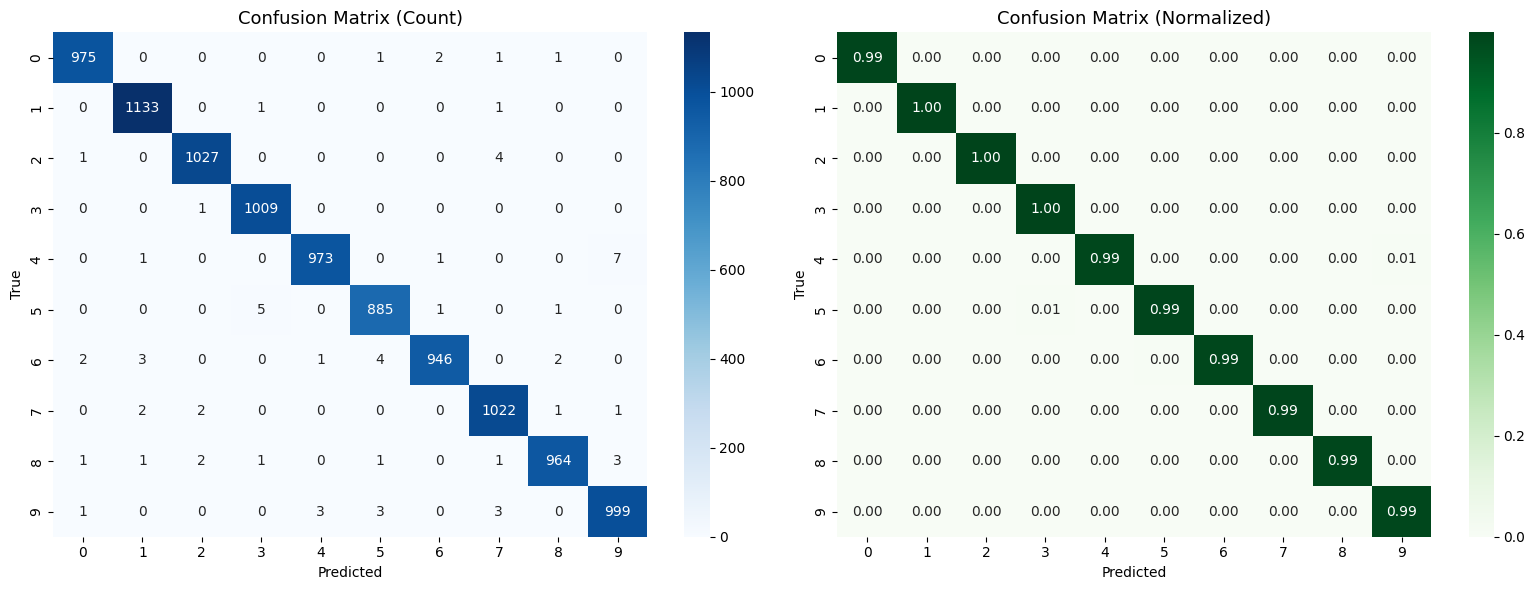

In [118]:
# 최종 검증 데이터로 예측
_, _, final_preds, final_labels, final_probs = evaluate(model, test_loader, criterion)

# ---- WandB 내장 Confusion Matrix ----
wandb.log({
    "eval/confusion_matrix": wandb.plot.confusion_matrix(
        probs=None,
        y_true=final_labels,
        preds=final_preds,
        class_names=class_names
    )
})

# ---- Matplotlib으로 상세 Confusion Matrix 이미지 로깅 ----
cm = confusion_matrix(final_labels, final_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
wandb.log({"eval/confusion_matrix_image": wandb.Image(fig)})
plt.show()
plt.close()

In [119]:
# ---- WandB 내장 PR Curve ----
wandb.log({
    "eval/pr_curve": wandb.plot.pr_curve(
        y_true=final_labels,
        y_probas=final_probs,
        labels=class_names,
        title="Precision-Recall Curve"
    )
})

# ---- WandB 내장 ROC Curve ----
wandb.log({
    "eval/roc_curve": wandb.plot.roc_curve(
        y_true=final_labels,
        y_probas=final_probs,
        labels=class_names,
        title="ROC Curve"
    )
})

In [120]:
model.eval()

# WandB Table로 예측 결과 시각화
table = wandb.Table(columns=["image", "true_label", "predicted", "correct", "confidence"])

test_iter = iter(test_loader)
sample_imgs, sample_labels = next(test_iter)
sample_imgs_device = sample_imgs[:20].to(DEVICE)

with torch.no_grad():
    outputs = model(sample_imgs_device)
    probs   = F.softmax(outputs, dim=1)
    preds   = outputs.argmax(dim=1).cpu().numpy()
    confs   = probs.max(dim=1).values.cpu().numpy()

for i in range(20):
    img_np = sample_imgs[i].squeeze().numpy()
    true_l = int(sample_labels[i])
    pred_l = int(preds[i])
    conf   = float(confs[i])
    correct = "True" if true_l == pred_l else "False"

    table.add_data(
        wandb.Image(img_np, caption=f"True:{true_l} Pred:{pred_l}"),
        true_l,
        pred_l,
        correct,
        round(conf, 4)
    )

wandb.log({"eval/predictions_table": table})

In [121]:
# 학습 히스토리를 WandB Table + Custom Chart로 로깅
epochs_list = list(range(1, cfg.epochs + 1))

# Loss 곡선
loss_table = wandb.Table(
    data=list(zip(epochs_list, history["train_loss"], history["val_loss"])),
    columns=["epoch", "train_loss", "val_loss"]
)
wandb.log({
    "charts/loss_curve": wandb.plot.line_series(
        xs=epochs_list,
        ys=[history["train_loss"], history["val_loss"]],
        keys=["Train Loss", "Val Loss"],
        title="Loss Curve",
        xname="Epoch"
    )
})

# Accuracy 곡선
wandb.log({
    "charts/accuracy_curve": wandb.plot.line_series(
        xs=epochs_list,
        ys=[history["train_acc"], history["val_acc"]],
        keys=["Train Accuracy", "Val Accuracy"],
        title="Accuracy Curve",
        xname="Epoch"
    )
})

# 클래스별 정확도 Bar Chart
class_report = classification_report(final_labels, final_preds, output_dict=True)
class_acc_data = [[str(i), class_report[str(i)]['precision'],
                   class_report[str(i)]['recall'],
                   class_report[str(i)]['f1-score']] for i in range(10)]

class_table = wandb.Table(
    data=class_acc_data,
    columns=["class", "precision", "recall", "f1_score"]
)
wandb.log({
    "eval/per_class_f1": wandb.plot.bar(
        class_table, "class", "f1_score",
        title="Per-Class F1 Score"
    )
})

In [122]:
model.eval()
imgs_raw,  sample_labels = next(iter(DataLoader(raw_test,     batch_size=20, shuffle=False)))
imgs_norm, _             = next(iter(DataLoader(test_dataset, batch_size=20, shuffle=False)))

with torch.no_grad():
    outputs = model(imgs_norm.to(DEVICE))
    probs   = F.softmax(outputs, dim=1)
    preds   = outputs.argmax(dim=1).cpu().numpy()
    confs   = probs.max(dim=1).values.cpu().numpy()

wandb.log({
    "eval/sample_predictions": [
        wandb.Image(
            imgs_raw[i].squeeze().numpy(),  # 0~1 범위
            caption=f"True: {int(sample_labels[i])} | Pred: {preds[i]} | Conf: {confs[i]:.4f}"
        ) for i in range(20)
    ]
})

In [123]:
# ---- 최종 Summary 메트릭 ----
wandb.summary["best_val_accuracy"]  = best_val_acc
wandb.summary["final_val_accuracy"] = history["val_acc"][-1]
wandb.summary["final_train_accuracy"] = history["train_acc"][-1]
wandb.summary["total_params"] = total_params
wandb.summary["classification_report"] = classification_report(final_labels, final_preds)

print(classification_report(final_labels, final_preds, target_names=class_names))

# ---- Model Artifact 등록 ----
model_artifact = wandb.Artifact(
    name="mnist-cnn-model",
    type="model",
    description="MNIST CNN Best Model",
    metadata={
        "best_val_accuracy": best_val_acc,
        "epochs": cfg.epochs,
        "architecture": cfg.architecture,
    }
)
model_artifact.add_file("best_model.pth")
run.log_artifact(model_artifact)

print("\nModel Artifact 등록 완료")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Model Artifact 등록 완료
Best Validation Accuracy: 0.9942


In [124]:
wandb.finish()
print("WandB 대시보드 결과 확인")
print(f"{run.url}")

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▄▄▅▅▅▆▆▆▆▆▆▇▇██
global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
model/total_params,▁
model/trainable_params,▁
train/epoch_accuracy,▁▅▆▇▇▇█████
train/epoch_loss,█▄▃▂▂▂▁▁▁▁▁
train/epoch_time_sec,█▂▂▁▁▁▁▂▁▁▃
train/grad_norm,█▆▅▂▂▄▁▄▃▁▆▃▄▁▆▄▃▅▁▁▁▁▁▆▁▅▄▅▂▂▁▁▂▃▅▂▁▂▁▄
train/learning_rate,███████████▄▄▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
train/step_accuracy,▁▂▄▅▅▇▇▇▇▇▇▇▇█▇▇▇███████████████████████
+4,...


WandB 대시보드 결과 확인
https://wandb.ai/chaeyoon_kim/mnist-wandb-tutorial/runs/6zhnw0lw
